# Machine Learning Project - Password Strength Classifiers

Simone Piras 70/90/00539, Giovanni Presenti 70/90/00556, Alessia Tiddia 70/90/00501

#### Introduction 
This work aims to compare different classifiers for password strength prediction using a dataset of passwords with their respective strength labels.

#### Initial operations

In [12]:
import pandas as pd
import os

# Constants to define the number of training and testing samples
N_TRAIN = 10000
N_TEST = 100000


# Load the dataset
dirname = os.getcwd()
filename = os.path.join(dirname, "Dataset/data.csv")
data = pd.read_csv(filename, on_bad_lines="skip")
# N_TEST =  len(data) - N_TRAIN

#### Feature extraction

In [13]:
import numpy as np


# Shuffle the dataset
data_shuffled = data.sample(frac=1)

# Ensure the 'password' column is treated as string
data_shuffled["password"] = data_shuffled["password"].astype(str)

# Extract features
pass_length_train = data_shuffled["password"].str.len().head(N_TRAIN).values
digits_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_train = data_shuffled["password"].head(N_TRAIN).apply(lambda x: len(set(x))).values

pass_length_test = data_shuffled["password"].str.len().tail(N_TEST).values
digits_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_test = data_shuffled["password"].tail(N_TEST).apply(lambda x: len(set(x))).values

# Normalize features by password length (avoid division by zero)
digits_train_norm = digits_train / np.where(pass_length_train == 0, 1, pass_length_train)
symbols_train_norm = symbols_train / np.where(pass_length_train == 0, 1, pass_length_train)
upper_train_norm = upper_train / np.where(pass_length_train == 0, 1, pass_length_train)
lower_train_norm = lower_train / np.where(pass_length_train == 0, 1, pass_length_train)
unique_ratio_train = unique_chars_train / np.where(pass_length_train == 0, 1, pass_length_train)

digits_test_norm = digits_test / np.where(pass_length_test == 0, 1, pass_length_test)
symbols_test_norm = symbols_test / np.where(pass_length_test == 0, 1, pass_length_test)
upper_test_norm = upper_test /  np.where(pass_length_test == 0, 1, pass_length_test)
lower_test_norm = lower_test /  np.where(pass_length_test == 0, 1, pass_length_test)
unique_ratio_test = unique_chars_test / np.where(pass_length_test == 0, 1, pass_length_test)




#### Test with password lenght, number of digits, number of symbols, number of uppercase, number of lowercase and number of unique characters 

In [ ]:
# Split the dataset into features and target variable
xtr = np.array([pass_length_train, digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_ratio_train]).T
xts = np.array([pass_length_test, digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_ratio_test]).T

ytr = data_shuffled["strength"].head(N_TRAIN).values
yts = data_shuffled["strength"].tail(N_TEST).values


#### Display Train and Test subsets by password length

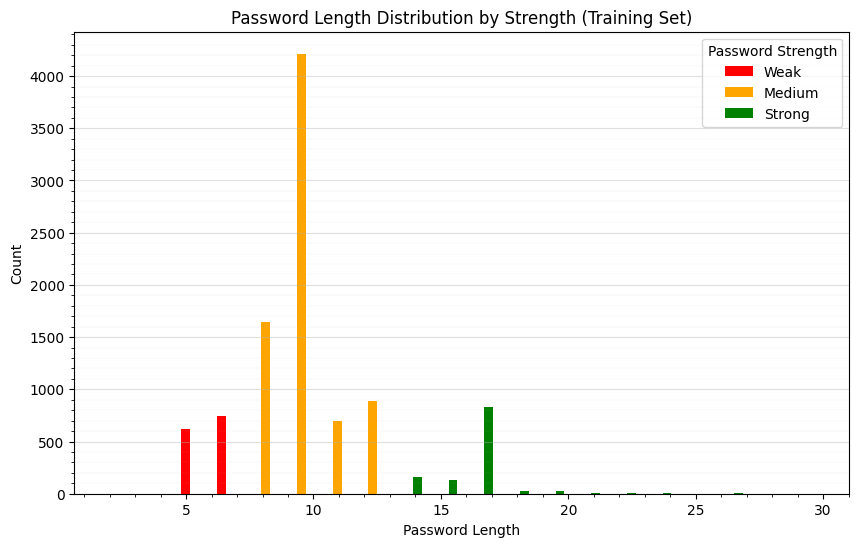

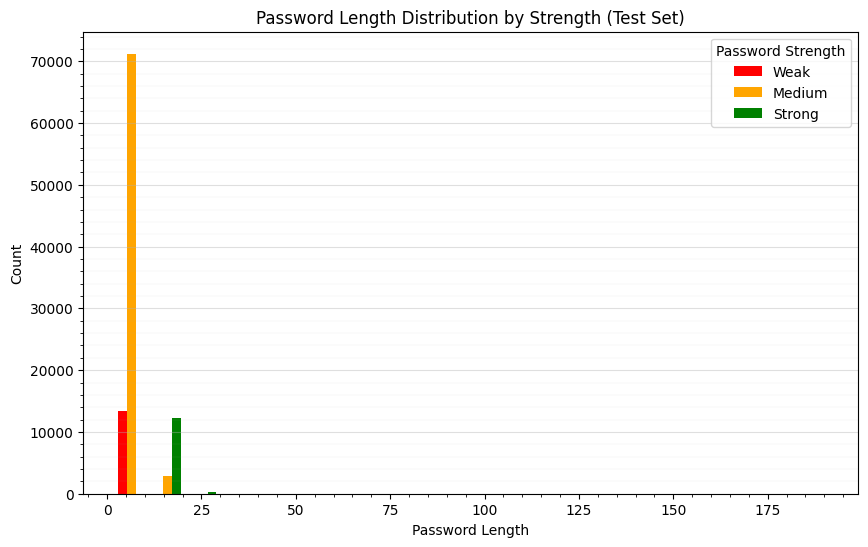

In [ ]:
import matplotlib.pyplot as plt


def plot_dataset(x, y, title, bins=20):
    """
    Plots the distribution of password lengths grouped by their strength categories.
    Parameters:
        x (np.ndarray): 2D array where the first column contains password lengths.
        y (np.ndarray): 1D array of class labels corresponding to password strength for each sample in x.
        title (str, optional): Title of the plot.
        bins (int, optional): Number of bins to use for the histogram. Default is 20.
        
    Displays:
        A bar plot showing the distribution of password lengths for each strength class, with different colors and a legend.
    """
    plt.figure(figsize=(10, 6))
    classes = np.unique(y) 
    colors = ["red", "orange", "green", "blue", "purple", "cyan", "magenta"]
    all_lengths = x[:, 0]
    bin_edges = np.histogram_bin_edges(all_lengths, bins=bins)
    width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)
    legend_names = ["Weak", "Medium", "Strong"]

    print(f"\nDistribution of password strengths in the dataset.")
    for i, k in enumerate(classes):
        count = np.sum(y == k)
        label = legend_names[i] if i < len(legend_names) else f"Class {k}"
        print(f"  {label}: {count} samples")
    
    for i, k in enumerate(classes):
        lengths = x[y == k, 0]
        hist, _ = np.histogram(lengths, bins=bin_edges)
        plt.bar(
            bin_edges[:-1] + i * width,
            hist,
            width=width,
            color=colors[i % len(colors)],
            align="edge",
            label=legend_names[i],
        )

    plt.xlabel("Password Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(title="Password Strength")
    plt.grid(axis="y", alpha=0.4)
    plt.minorticks_on()  # Enable minor ticks
    plt.grid(which="minor", axis="y", alpha=0.2, linewidth=0.3)  # Minor grid
    plt.show()

# Plot the distributions of password lengths for training and test sets
plot_dataset(xtr, ytr, title="Password Length Distribution by Strength (Training Set)")
plot_dataset(xts, yts, title="Password Length Distribution by Strength (Test Set)")

#### Classifiers definition

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Define the classifiers with their parameters
KNN_clf = KNeighborsClassifier(n_neighbors=5)
SVM_clf = SVC(kernel="rbf")
DT_clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
GNB_clf = GaussianNB()
SGD_reg = SGDClassifier(loss="hinge", penalty="l2")

# List of classifiers to be trained and tested
clfs = [KNN_clf, SVM_clf, DT_clf, GNB_clf, SGD_reg]

#### Classifiers training

In [17]:
import time

# Fit each classifier, make predictions, and evaluate performance
def train(xtr,ytr):
    for clf in clfs:

        print("\n")
        print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
        tic = time.perf_counter()
        clf.fit(xtr, ytr)
        toc = time.perf_counter()
        print(f"\tTraining time:\t {toc-tic:.4f} seconds")

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0155 seconds


---		SVC		---

	Training time:	 0.1495 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0041 seconds


---		GaussianNB		---

	Training time:	 0.0035 seconds


---		SGDClassifier		---

	Training time:	 0.0750 seconds


#### Classifiers evaluation



---		KNeighborsClassifier		---

	Prediction time: 7.0097 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13346
      Medium      1.000     1.000     1.000     74163
      Strong      1.000     1.000     1.000     12491

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



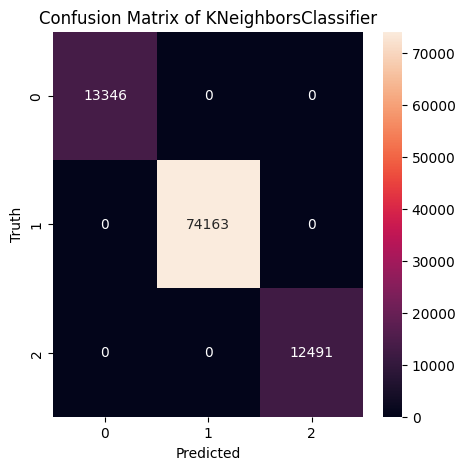



---		SVC		---

	Prediction time: 3.4683 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13346
      Medium      1.000     1.000     1.000     74163
      Strong      1.000     1.000     1.000     12491

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



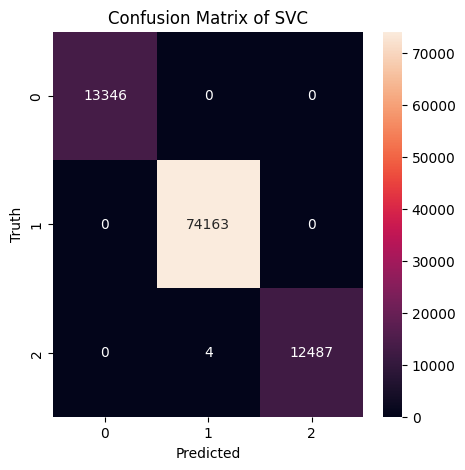



---		DecisionTreeClassifier		---

	Prediction time: 0.0075 seconds


              precision    recall  f1-score   support

        Weak      1.000     1.000     1.000     13346
      Medium      1.000     1.000     1.000     74163
      Strong      1.000     1.000     1.000     12491

    accuracy                          1.000    100000
   macro avg      1.000     1.000     1.000    100000
weighted avg      1.000     1.000     1.000    100000



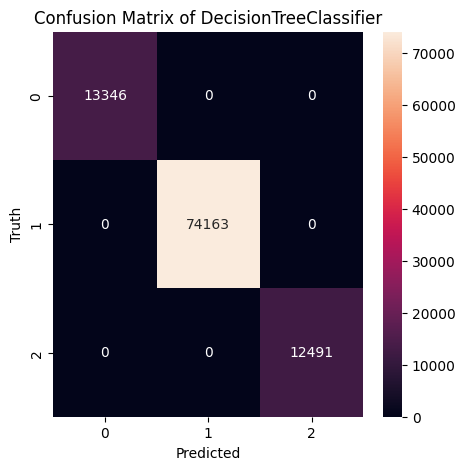



---		GaussianNB		---

	Prediction time: 0.0266 seconds


              precision    recall  f1-score   support

        Weak      0.976     0.924     0.949     13346
      Medium      0.984     0.983     0.983     74163
      Strong      0.913     0.969     0.940     12491

    accuracy                          0.973    100000
   macro avg      0.958     0.959     0.958    100000
weighted avg      0.974     0.973     0.973    100000



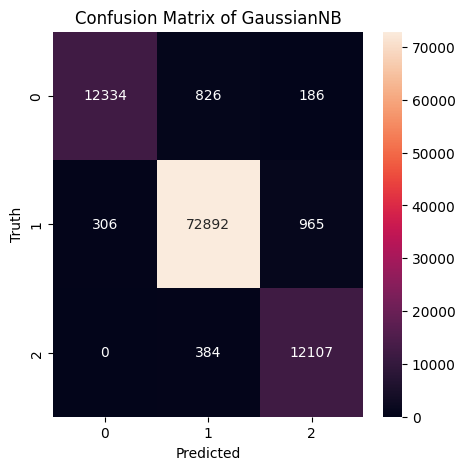



---		SGDClassifier		---

	Prediction time: 0.0058 seconds


              precision    recall  f1-score   support

        Weak      0.980     1.000     0.990     13346
      Medium      1.000     0.996     0.998     74163
      Strong      1.000     0.999     1.000     12491

    accuracy                          0.997    100000
   macro avg      0.993     0.999     0.996    100000
weighted avg      0.997     0.997     0.997    100000



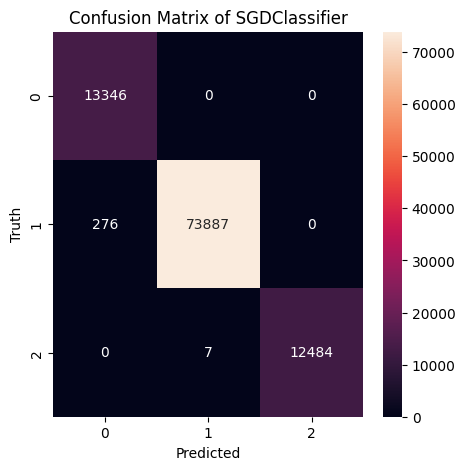

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


def plot_confusion_matrix(y_test, y_pred, classifier_name):
    """
    Plots the confusion matrix for a given set of true and predicted labels using a heatmap.

    Args:
        y_test (array-like): True labels of the test dataset.
        y_pred (array-like): Predicted labels from the classifier.
        classifier_name (str): Name of the classifier to display in the plot title.

    Returns:
        None: Displays the confusion matrix plot.
    """
    plt.figure(figsize=(5, 5))
    plt.title("Confusion Matrix of " + classifier_name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()


# Fit each classifier, make predictions, and evaluate performance
def test(xts, yts):
    for clf in clfs:
        print("\n")
        print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
        tic = time.perf_counter()
        predictions = clf.predict(xts)
        toc = time.perf_counter()
        print(f"\tPrediction time: {toc-tic:.4f} seconds")
        print("\n")
        print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"], digits=3))
        plot_confusion_matrix(yts, predictions, clf.__class__.__name__)

test(xts, yts)

#### Features importance evaluation

Importances: [0.416 0.    0.    0.    0.    0.   ]


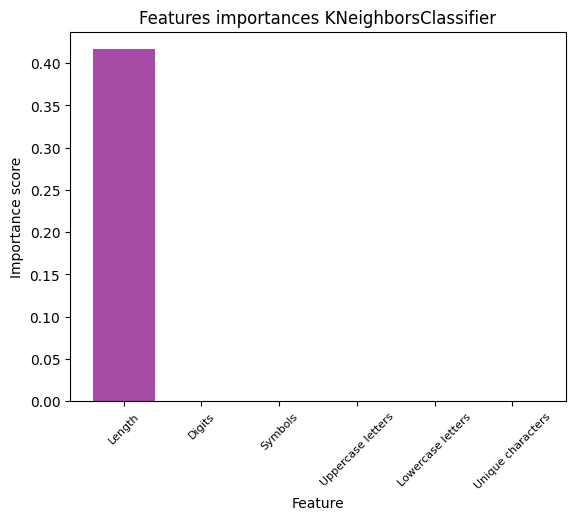

Importances: [0.416 0.    0.    0.    0.    0.   ]


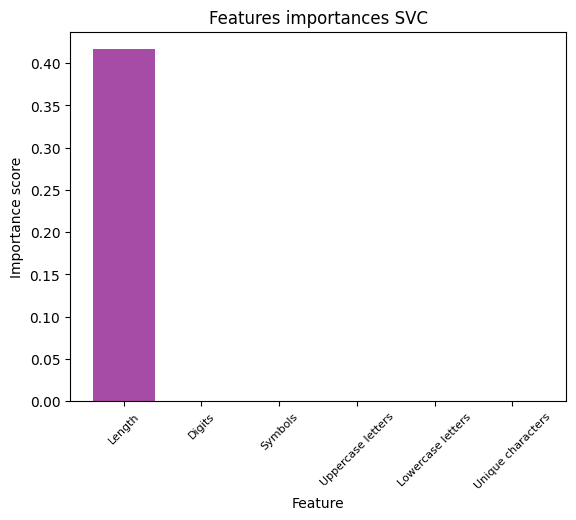

Importances: [0.416 0.    0.    0.    0.    0.   ]


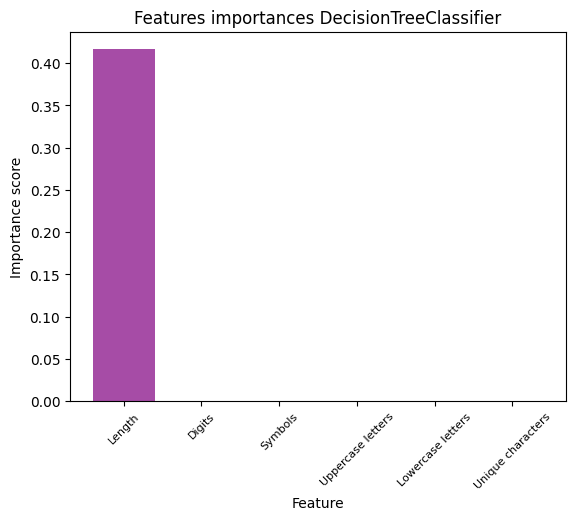

Importances: [0.285 0.017 0.01  0.056 0.024 0.   ]


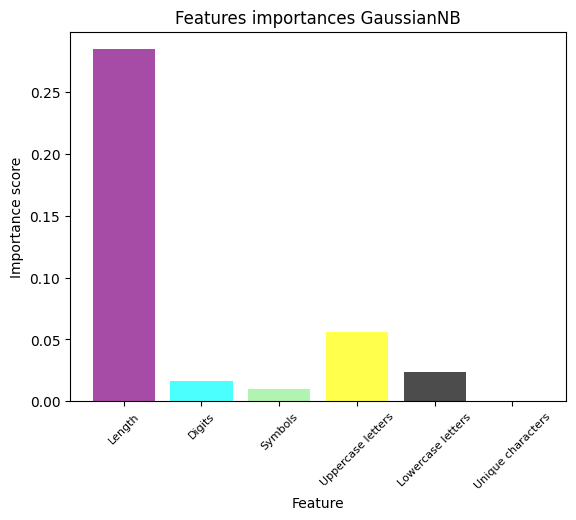

Importances: [0.405 0.016 0.    0.016 0.015 0.   ]


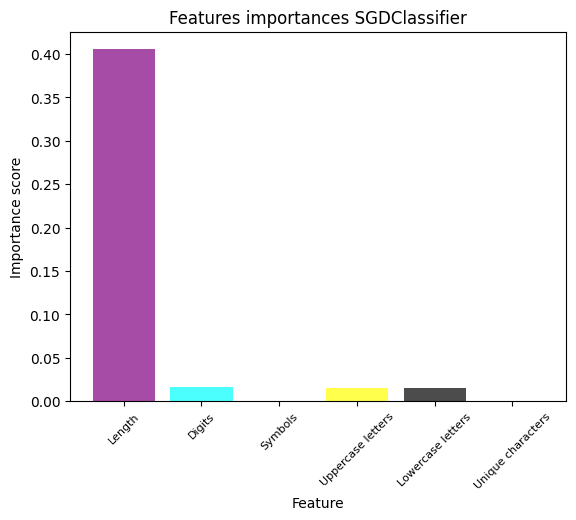

In [ ]:
from sklearn.inspection import permutation_importance

def feature_importance_histogram(importances, feature_names=None, title=None):
    """
    Plots a histogram of feature importances.
    Parameters
    ----------
    importances: list or array-like
        The importance scores for each feature.
    feature_names: list of str, optional
        Names of the features to use as x-axis labels.
    title : str, optional
        The title of the plot.
    """
    colors = ["purple", "cyan", "lightgreen", "yellow", "black", "red", "blue", "orange"]
    n_features = len(importances)
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(n_features)]

    plt.bar(
        range(n_features),
        importances,
        tick_label=feature_names,
        color=colors[:n_features],
        linewidth=1.2,
        alpha=0.7,
    )
    plt.xlabel("Feature")
    plt.ylabel("Importance score")
    plt.title(title)
    plt.xticks(fontsize=8, rotation=45)
    plt.show()

# Calculate and plot feature importances for each classifier
def feature_importance(xts, yts):
    for clf in clfs:
        results = permutation_importance(clf, xts, yts, n_repeats=5, random_state=0)
        importances = results.importances_mean
        print("Importances:", np.round(importances, 3))
        if xts.shape[1] == 6:
            feature_names=["Length", "Digits", "Symbols", "Uppercase letters", "Lowercase letters", "Unique characters"]
        elif xts.shape[1] == 5:
            feature_names=["Digits", "Symbols", "Uppercase letters", "Lowercase letters", "Unique characters"]
        feature_importance_histogram(importances, feature_names, title=f"Features importances {clf.__class__.__name__}")

feature_importance(xts, yts)

#### Tests with Digits, Symbols, Upper, Lower and Unique characters as Features.

In [20]:
# Split the dataset into features and target variable
xtr = np.array([digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_chars_train]).T
xts = np.array([digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_chars_test]).T

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0132 seconds


---		SVC		---

	Training time:	 1.0356 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0049 seconds


---		GaussianNB		---

	Training time:	 0.0022 seconds


---		SGDClassifier		---

	Training time:	 0.1271 seconds




---		KNeighborsClassifier		---

	Prediction time: 6.2270 seconds


              precision    recall  f1-score   support

        Weak      0.914     0.980     0.946     13346
      Medium      0.987     0.981     0.984     74163
      Strong      0.984     0.945     0.964     12491

    accuracy                          0.976    100000
   macro avg      0.962     0.969     0.965    100000
weighted avg      0.977     0.976     0.976    100000



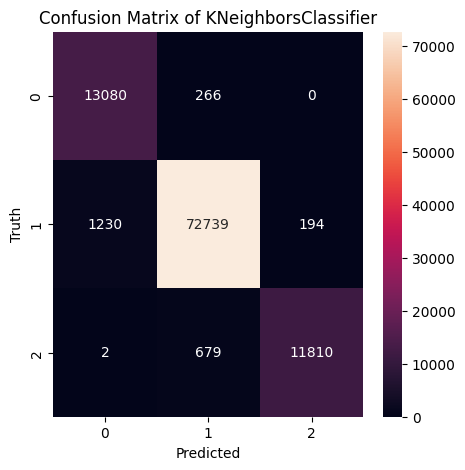



---		SVC		---

	Prediction time: 25.6822 seconds


              precision    recall  f1-score   support

        Weak      0.671     0.604     0.636     13346
      Medium      0.914     0.944     0.929     74163
      Strong      0.983     0.898     0.938     12491

    accuracy                          0.893    100000
   macro avg      0.856     0.815     0.834    100000
weighted avg      0.890     0.893     0.891    100000



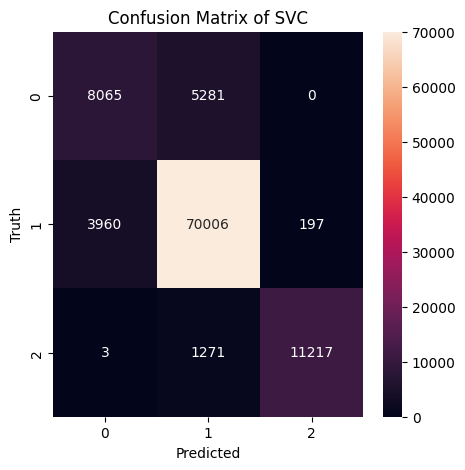



---		DecisionTreeClassifier		---

	Prediction time: 0.0077 seconds


              precision    recall  f1-score   support

        Weak      0.529     0.875     0.660     13346
      Medium      0.973     0.853     0.909     74163
      Strong      0.962     0.994     0.978     12491

    accuracy                          0.874    100000
   macro avg      0.821     0.907     0.849    100000
weighted avg      0.913     0.874     0.885    100000



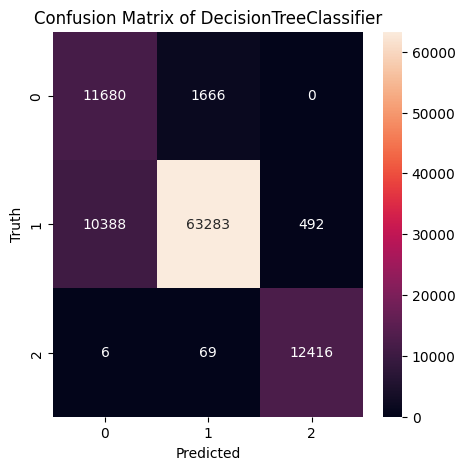



---		GaussianNB		---

	Prediction time: 0.0195 seconds


              precision    recall  f1-score   support

        Weak      0.659     0.231     0.342     13346
      Medium      0.865     0.968     0.913     74163
      Strong      0.914     0.906     0.910     12491

    accuracy                          0.862    100000
   macro avg      0.813     0.702     0.722    100000
weighted avg      0.844     0.862     0.837    100000



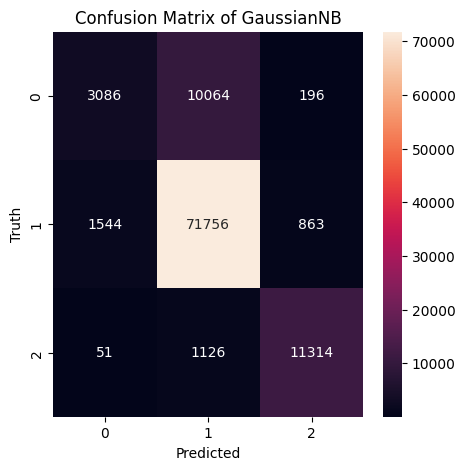



---		SGDClassifier		---

	Prediction time: 0.0057 seconds


              precision    recall  f1-score   support

        Weak      0.682     0.469     0.556     13346
      Medium      0.891     0.959     0.923     74163
      Strong      0.985     0.868     0.923     12491

    accuracy                          0.882    100000
   macro avg      0.853     0.765     0.801    100000
weighted avg      0.875     0.882     0.874    100000



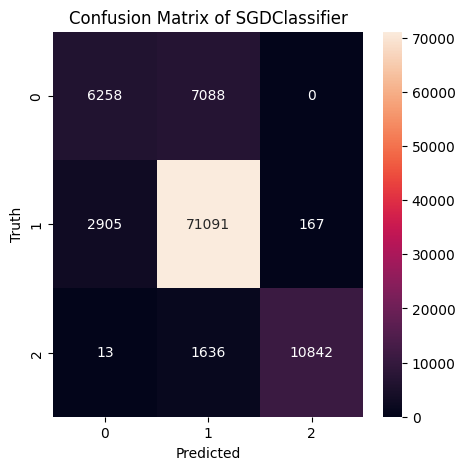

In [21]:
# Fit each classifier, make predictions, and evaluate performance
test(xts, yts)

Importances: [0.137 0.003 0.02  0.147 0.274]


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (6,)  and requested shape (5,)

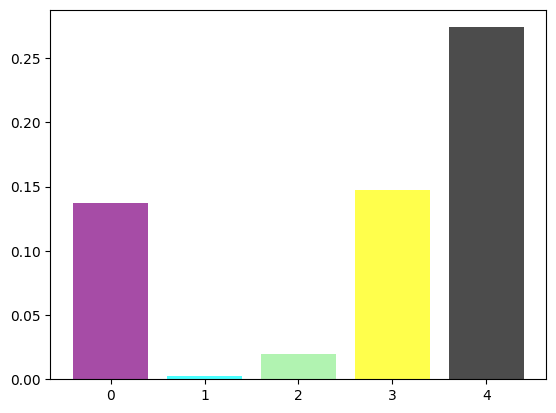

In [22]:
# Calculate and plot feature importances for each classifier
feature_importance(xts, yts)

#### Tests with only Password Length as a Feature.

In [ ]:
# Split the dataset into features and target variable
xtr = np.array([pass_length_train]).T
xts = np.array([pass_length_test]).T

train(xtr, ytr)

In [ ]:
# Fit each classifier, make predictions, and evaluate performance
test(xts, yts)